In [3]:
# ... (Previous code remains the same: Imports, Loading, PCA calculation) ...

# --- MODERN PLOTLY VISUALIZATION ---
import plotly.express as px
import plotly.io as pio

# Set modern template
pio.templates.default = "plotly_white"

print("\nGenerating Interactive Domain Shift Plot...")

# Create Interactive Scatter Plot
fig = px.scatter(
    pca_df, 
    x='PC1', 
    y='PC2', 
    color='Cohort',
    symbol='Cohort', # Different shapes for different sources
    color_discrete_map={
        'Public (Western)': '#3498db',        # Professional Blue
        'Local (Square Hospital)': '#e74c3c'  # Professional Red
    },
    title='<b>Domain Shift Visualization</b>: Western vs. Bangladeshi Radiomics',
    labels={
        'PC1': f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)',
        'PC2': f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)'
    },
    opacity=0.7,
    width=900,
    height=700
)

# Polish the Design
fig.update_traces(marker=dict(size=8, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(
    font=dict(family="Arial", size=14, color="#333"),
    title=dict(x=0.5, font=dict(size=20)), # Center title
    legend=dict(
        title=dict(text='Data Source'),
        yanchor="top", y=0.99,
        xanchor="right", x=0.99,
        bgcolor="rgba(255,255,255,0.8)"
    ),
    xaxis=dict(showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(showgrid=True, gridcolor='#f0f0f0')
)

# Show
fig.show()

# Save High-Res
output_html = "../Results/Figure_Radiomics_DomainShift_Interactive.html"
output_png = "../Results/Figure_Radiomics_DomainShift.png"

fig.write_html(output_html)
print(f"Interactive Graph saved to: {output_html}")

try:
    fig.write_image(output_png, scale=3)
    print(f"Static Image saved to: {output_png}")
except:
    print("Install 'kaleido' to save static PNGs.")


Generating Interactive Domain Shift Plot...


Interactive Graph saved to: ../Results/Figure_Radiomics_DomainShift_Interactive.html
Static Image saved to: ../Results/Figure_Radiomics_DomainShift.png


--- FINAL DOMAIN SHIFT ANALYSIS ---
Loaded Public: 421 patients
Loaded Local:  22 patients
Common Features found: 107
Merged dataset saved to: ../Results/final_radiomics_merged.csv

Running PCA...


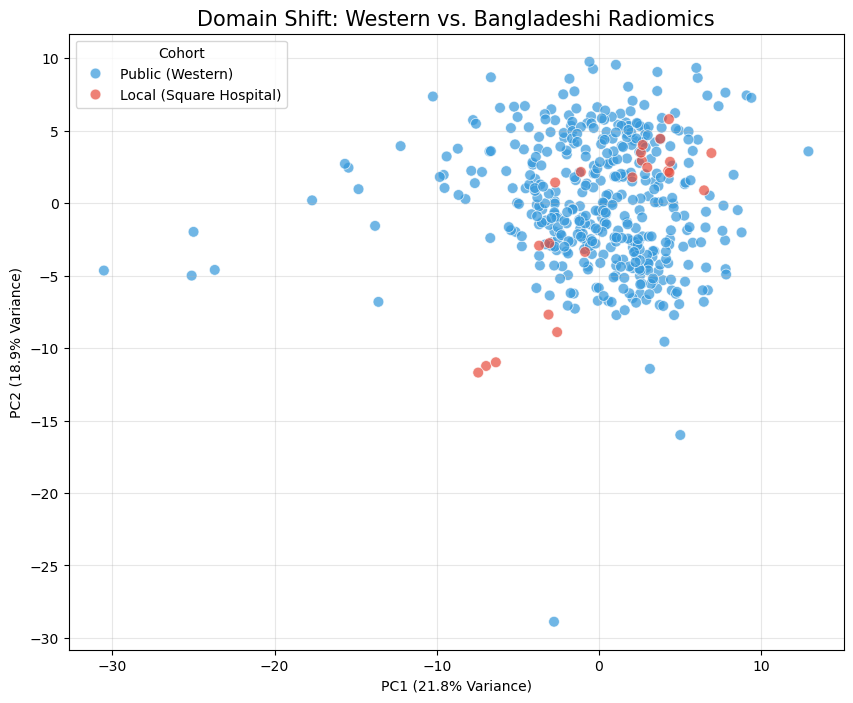

PCA Plot Saved.

Calculating Feature Differences...
Top 5 Most Shifted Features:


,Feature,P_Value,Fold_Change
91,original_gldm_LargeDependenceLowGrayLevelEmphasis,3.121929e-22,0.234300
22,original_shape_Maximum2DDiameterColumn,1.938568e-21,0.409488
49,original_shape_SurfaceVolumeRatio,1.348309e-19,0.534972
25,original_glcm_ClusterProminence,2.114796e-19,0.304269
98,original_shape_Sphericity,2.317238e-19,1.834320


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind

# --- CONFIGURATION ---
# 1. Public Data (From Task 10)
public_path = '../Results/radiomics_features.csv' 

# 2. Local Data (From the currently running Task 35)
local_path = '../Results/square_radiomics_clean.csv'

# Output
merged_output = '../Results/final_radiomics_merged.csv'
stats_output = '../Results/domain_shift_stats.csv'

print("--- FINAL DOMAIN SHIFT ANALYSIS ---")

try:
    # Load Datasets
    df_public = pd.read_csv(public_path)
    df_local = pd.read_csv(local_path)
    
    # Label Cohorts
    df_public['Cohort'] = 'Public (Western)'
    df_local['Cohort'] = 'Local (Square Hospital)'
    
    print(f"Loaded Public: {len(df_public)} patients")
    print(f"Loaded Local:  {len(df_local)} patients")
    
    # Harmonize Columns (Find common features)
    public_feats = [c for c in df_public.columns if 'original_' in c]
    local_feats = [c for c in df_local.columns if 'original_' in c]
    common_feats = list(set(public_feats) & set(local_feats))
    
    print(f"Common Features found: {len(common_feats)}")
    
    if len(common_feats) == 0:
        raise ValueError("No common features found! Check column names.")

    # Merge
    cols = ['PatientID', 'Cohort'] + common_feats
    df_merged = pd.concat([df_public[cols], df_local[cols]], axis=0).reset_index(drop=True)
    df_merged = df_merged.fillna(0)
    
    df_merged.to_csv(merged_output, index=False)
    print(f"Merged dataset saved to: {merged_output}")

    # --- PCA ANALYSIS ---
    print("\nRunning PCA...")
    X = df_merged[common_feats]
    y = df_merged['Cohort']
    
    # Standardize Features (Z-Score)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduce to 2 Dimensions
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_scaled)
    
    pca_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'])
    pca_df['Cohort'] = y.values
    
    # --- PLOT ---
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=pca_df, x='PC1', y='PC2', hue='Cohort',
        palette=['#3498db', '#e74c3c'], alpha=0.7, s=60
    )
    plt.title('Domain Shift: Western vs. Bangladeshi Radiomics', fontsize=15)
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
    plt.grid(True, alpha=0.3)
    
    plt.savefig('../Results/Figure_Radiomics_DomainShift.png', dpi=300)
    plt.show()
    print("PCA Plot Saved.")

    # --- STATISTICS ---
    print("\nCalculating Feature Differences...")
    stats = []
    for f in common_feats:
        v_pub = df_merged[df_merged['Cohort'] == 'Public (Western)'][f]
        v_loc = df_merged[df_merged['Cohort'] == 'Local (Square Hospital)'][f]
        
        t_stat, p_val = ttest_ind(v_pub, v_loc, equal_var=False)
        stats.append({
            'Feature': f, 
            'P_Value': p_val, 
            'Fold_Change': v_loc.mean() / (v_pub.mean() + 1e-9)
        })
        
    df_stats = pd.DataFrame(stats).sort_values(by='P_Value')
    df_stats.to_csv(stats_output, index=False)
    
    print("Top 5 Most Shifted Features:")
    display(df_stats.head())

except Exception as e:
    print(f"Error: {e}")

In [6]:
# ... (Previous code: Imports, Loading, PCA calculation) ...

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

print("\nGenerating Combo Plot (Scatter + Table)...")

# 1. Prepare Statistics Table Data
# We grab the top 5 most different features calculated earlier
top_stats = df_stats.head(5).copy()
# Format numbers for clean display
top_stats['P_Value'] = top_stats['P_Value'].apply(lambda x: f"{x:.2e}")
top_stats['Fold_Change'] = top_stats['Fold_Change'].apply(lambda x: f"{x:.2f}x")
# Rename columns for the table
table_headers = ['Radiomic Feature', 'P-Value', 'Fold Change (Local/Public)']
table_values = [
    top_stats['Feature'].str.replace('original_', '').str[:30] + '...', # Shorten names
    top_stats['P_Value'],
    top_stats['Fold_Change']
]

# 2. Create Subplot Layout (Row 1: Scatter, Row 2: Table)
fig = make_subplots(
    rows=2, cols=1,
    row_heights=[0.7, 0.3], # 70% Chart, 30% Table
    vertical_spacing=0.1,
    specs=[[{"type": "scatter"}],
           [{"type": "table"}]]
)

# 3. Add Scatter Plot (Row 1)
# Add Public
fig.add_trace(
    go.Scatter(
        x=pca_df[pca_df['Cohort']=='Public (Western)']['PC1'],
        y=pca_df[pca_df['Cohort']=='Public (Western)']['PC2'],
        mode='markers',
        name='Public (Western)',
        marker=dict(color='#3498db', size=8, opacity=0.6)
    ),
    row=1, col=1
)

# Add Local
fig.add_trace(
    go.Scatter(
        x=pca_df[pca_df['Cohort']=='Local (Square Hospital)']['PC1'],
        y=pca_df[pca_df['Cohort']=='Local (Square Hospital)']['PC2'],
        mode='markers',
        name='Local (Square)',
        marker=dict(color='#e74c3c', size=8, opacity=0.7, symbol='diamond')
    ),
    row=1, col=1
)

# 4. Add Table (Row 2)
fig.add_trace(
    go.Table(
        header=dict(
            values=table_headers,
            fill_color='paleturquoise',
            align='left',
            font=dict(size=12, color='black')
        ),
        cells=dict(
            values=table_values,
            fill_color='lavender',
            align='left',
            font=dict(size=11)
        )
    ),
    row=2, col=1
)

# 5. Update Layout
fig.update_layout(
    title_text="<b>Domain Shift Analysis:</b> Radiomic Feature Distribution & Top Drivers",
    title_x=0.5,
    height=900,
    width=800,
    showlegend=True,
    template="plotly_white",
    xaxis=dict(title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} Variance)"),
    yaxis=dict(title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} Variance)")
)

# Show & Save
fig.show()

output_html = "../Results/Figure_Radiomics_DomainShift_Combo.html"
output_png = "../Results/Figure_Radiomics_DomainShift_Combo.png"

fig.write_html(output_html)
print(f"Interactive Combo Chart saved to: {output_html}")

try:
    fig.write_image(output_png, scale=2)
    print(f"Static Combo Image saved to: {output_png}")
except:
    print("Install 'kaleido' to save static image.")


Generating Combo Plot (Scatter + Table)...


Interactive Combo Chart saved to: ../Results/Figure_Radiomics_DomainShift_Combo.html
Static Combo Image saved to: ../Results/Figure_Radiomics_DomainShift_Combo.png
